In [ ]:
#Dataset Collection
#converting the data into csv form

In [5]:
import pandas as pd
adult_lit_rate = pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-adults.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent' : 'Our World in Data data fetch/1.0'})
#adult_lit_rate

In [4]:
adult_lit_rate.to_csv("adult_literacy_rate.csv")

In [118]:
youth_lit_rate = pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-of-young-men-and-women.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent' : 'Our World in Data data fetch/1.0'})
#youth_lit_rate

In [8]:
youth_lit_rate.to_csv("youth_literacy_rate.csv")

In [119]:
illiterate_population = pd.read_csv("https://ourworldindata.org/grapher/literate-and-illiterate-world-population.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent' : 'Our World in Data data fetch/1.0'})
#illiterate_population

In [11]:
illiterate_population.to_csv("illiterate_population.csv")

In [120]:
gdp_per_capita = pd.read_csv("https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent' : 'Our World in Data data fetch/1.0'})
#gdp_per_capita

In [14]:
gdp_per_capita.to_csv("gdp_per_capita.csv")

In [121]:
avg_year_school = pd.read_csv("https://ourworldindata.org/grapher/literacy-rates-vs-average-years-of-schooling.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent' : 'Our World in Data data fetch/1.0'})
#avg_year_school

In [390]:
avg_year_school.to_csv("avg_year_school.csv")

In [286]:
#reading the csv file and converting it to datframes

In [6]:
import pandas as pd

df_adult_lit_rate = pd.read_csv("adult_literacy_rate.csv")
#df_adult_lit_rate

In [7]:
df_youth_lit_rate = pd.read_csv("youth_literacy_rate.csv")
#df_youth_lit_rate

In [8]:
df_illiterate_population = pd.read_csv("illiterate_population.csv")
#df_illiterate_population

In [9]:
df_gdp_per_capita = pd.read_csv("gdp_per_capita.csv")
#df_gdp_per_capita

In [10]:
df_avg_year_school = pd.read_csv("avg_year_school.csv")
#df_avg_year_school

In [11]:
#Data Understanding 
#Combining the 5 Dataframes into 3 dataframes

In [12]:
df_literacy = pd.merge(df_adult_lit_rate, df_youth_lit_rate, on = ['entity', 'code', 'year'], how = 'inner')
#df_literacy

In [21]:
df_illiteracy = df_illiterate_population   #we can avoid this step by directly naming DF in step 23
#df_illiteracy

In [13]:
df_gdp_schooling = pd.merge(df_gdp_per_capita, df_avg_year_school, on = ['entity', 'code', 'year', 'owid_region'], how = 'inner')
#df_gdp_schooling

In [14]:
# Data Cleaning 

In [22]:
#Handle missing values: Drop or impute.
#using impute as drop may remove some important records
df_literacy = df_literacy.fillna(0)
df_illiteracy = df_illiteracy.fillna(0)
df_gdp_schooling = df_gdp_schooling.fillna(0)
#df_literacy
#df_illiteracy
#df_gdp_schooling

In [23]:
#Removing duplicates
df_literacy = df_literacy.drop_duplicates()
df_illiteracy = df_illiteracy.drop_duplicates()
df_gdp_schooling = df_gdp_schooling.drop_duplicates()
#df_literacy
#df_illiteracy
#df_gdp_schooling

In [24]:
#Renaming Column Names
df_literacy = df_literacy.rename(columns = {"entity" : "Country", 
                              "adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99" : "Adult Literacy Rate", 
                              "youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m" : "Youth Literacy Rate Male",
                              "youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f" : "Youth Literacy Rate Female"
                             })
df_illiteracy = df_illiteracy.rename(columns = {"entity" : "Country",
                                                "illiteracy_rate" : "Illiteracy Rate",
                                                "literacy_rate" : "Literacy Rate"
                                               })
df_gdp_schooling = df_gdp_schooling.rename(columns = {"entity" : "Country",
                                                      "ny_gdp_pcap_pp_kd" : "GDP",
                                                      "literacy_rate" : "Literacy Rate",
                                                      "mf_youth_and_adults__15_64_years__average_years_of_education" : "Avg Year of Education",
                                                      "population_historical" : "Population"
                                                     })
#df_literacy.info()
#df_illiteracy.info()
#df_gdp_schooling.info()

In [72]:
#Filter years between 1990 - 2023
df_literacy = df_literacy[(df_literacy["year"] >= 1990) & (df_literacy["year"]<=2023)]
df_illiteracy = df_illiteracy[(df_illiteracy["year"] >= 1990) & (df_illiteracy["year"]<=2023)]
df_gdp_schooling = df_gdp_schooling[(df_gdp_schooling["year"] >= 1990) & (df_gdp_schooling["year"]<=2023)] 
df_literacy = df_literacy.fillna(0)
df_illiteracy = df_illiteracy.fillna(0)
#df_illiteracy = df_illiteracy.drop(columns=["Unnamed: 0"])
df_literacy
#df_illiteracy
#df_gdp_schooling

,Unnamed: 0_x,Country,code,year,Adult Literacy Rate,Unnamed: 0_y,Youth Literacy Rate Male,Youth Literacy Rate Female,owid_region
1,1,Afghanistan,AFG,2011,31.00000,1,62.00000,32.00000,Asia
2,2,Afghanistan,AFG,2015,33.75384,2,57.73505,25.48416,Asia
3,3,Afghanistan,AFG,2021,37.00000,3,71.00000,42.00000,Asia
4,4,Albania,ALB,2001,99.00000,5,99.00000,99.00000,Europe
5,5,Albania,ALB,2008,96.00000,7,99.00000,99.00000,Europe
...,...,...,...,...,...,...,...,...,...
1702,1719,Zambia,ZMB,2002,69.00000,1994,78.00000,66.00000,Africa
1703,1720,Zambia,ZMB,2010,83.00000,1995,91.00000,87.00000,Africa
1704,1721,Zambia,ZMB,2018,71.13230,1996,82.44786,72.90992,Africa
1706,1723,Zimbabwe,ZWE,1992,84.00000,1998,97.00000,94.00000,Africa


In [387]:
#Education Index - Measures education quality by considering both access (literacy) and duration (schooling).
df_education_index = df_gdp_schooling


In [88]:
#deleting the "Unnamed: 0" column

df_literacy = df_literacy.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])
#df_illiteracy = df_illiteracy.drop(columns=[" "])
df_gdp_schooling = df_gdp_schooling.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])

In [303]:
#mean = df_literacy[["Adult Literacy Rate", "Youth Literacy Rate Male", "Youth Literacy Rate Female"]].mean()
#mean 

In [304]:
df_literacy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1405 entries, 1 to 1707
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country                     1405 non-null   object 
 1   code                        1405 non-null   object 
 2   year                        1405 non-null   int64  
 3   Adult Literacy Rate         1405 non-null   float64
 4   Youth Literacy Rate Male    1405 non-null   float64
 5   Youth Literacy Rate Female  1405 non-null   float64
 6   owid_region                 1405 non-null   object 
dtypes: float64(3), int64(1), object(3)
memory usage: 87.8+ KB


In [305]:
df_illiteracy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1419 entries, 2 to 2058
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       1419 non-null   int64  
 1   Country          1419 non-null   object 
 2   code             1419 non-null   object 
 3   year             1419 non-null   int64  
 4   Illiteracy Rate  1419 non-null   float64
 5   Literacy Rate    1419 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 77.6+ KB


In [306]:
df_gdp_schooling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1594 entries, 0 to 1593
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                1594 non-null   object 
 1   code                   1594 non-null   object 
 2   year                   1594 non-null   int64  
 3   GDP                    1594 non-null   float64
 4   owid_region            1594 non-null   object 
 5   Literacy Rate          1594 non-null   float64
 6   Avg Year of Education  1594 non-null   float64
 7   Population             1594 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 99.8+ KB


In [307]:
df_literacy.shape

(1405, 7)

In [308]:
df_illiteracy.shape

(1419, 6)

In [309]:
df_gdp_schooling.shape

(1594, 8)

In [89]:
describe_lit = df_literacy.describe()
describe_lit

,year,Adult Literacy Rate,Youth Literacy Rate Male,Youth Literacy Rate Female
count,1405.000000,1405.000000,1405.000000,1405.000000
mean,2008.554448,80.042404,90.387280,86.272507
std,9.109381,18.086364,11.916495,17.411604
min,1990.000000,11.000000,25.000000,9.000000
25%,2001.000000,67.267330,86.000000,76.613550
50%,2010.000000,86.747480,96.000000,95.528910
75%,2016.000000,94.771680,98.783860,99.000000
max,2023.000000,100.000000,100.000000,100.000000


In [90]:
describe_illit = df_illiteracy.describe()
describe_illit

,Unnamed: 0,year,Illiteracy Rate,Literacy Rate
count,1419.000000,1419.000000,1419.000000,1419.000000
mean,1043.487667,2008.534179,20.013274,79.986726
std,588.253045,9.101880,18.144772,18.144772
min,2.000000,1990.000000,0.000000,11.000000
25%,519.500000,2001.000000,5.263798,67.227155
50%,1063.000000,2010.000000,13.348106,86.651890
75%,1547.000000,2016.000000,32.772847,94.736200
max,2058.000000,2023.000000,89.000000,100.000000


In [312]:
describe_gdp_schooling = df_gdp_schooling.describe()
describe_gdp_schooling

,year,GDP,Literacy Rate,Avg Year of Education,Population
count,1594.000000,1594.000000,1594.000000,1594.000000,1.594000e+03
mean,2007.806148,19394.244071,46.380390,4.159046,1.602582e+08
std,9.606936,23056.714443,42.619016,4.612806,5.166721e+08
min,1990.000000,525.418700,0.000000,0.000000,1.190000e+04
25%,2000.000000,4497.536900,0.000000,0.000000,4.760003e+06
50%,2010.000000,11188.098500,54.941160,1.740000,1.268708e+07
75%,2015.000000,22813.087500,92.000000,8.547500,4.742170e+07
max,2023.000000,155385.330000,100.000000,13.740000,3.083155e+09


In [313]:
#Literacy Gender Gap 
df_literacy["Literacy Gender Gap"] = df_literacy["Youth Literacy Rate Male"] - df_literacy["Youth Literacy Rate Female"]
#df_literacy

In [71]:
df_literacy_gender = df_literacy


In [315]:
# Male Female who is literate
df_literacy_gender["Male/Female literacy"] = df_literacy_gender["Literacy Gender Gap"].apply(lambda x : "Male" if x>0 else ("female" if x<0 else "Equal"))
#df_literacy_gender

In [393]:
#literacy growth rate
df_literacy_growth_rate = df_illiteracy
df_literacy_growth_rate["Literacy Growth Rate"] = df_literacy_growth_rate.groupby("Country")["Literacy Rate"].pct_change() * 100
df_literacy_growth_rate = df_literacy_growth_rate.fillna(0)

In [394]:
literacy_growth_mean_year = df_literacy_growth_rate.groupby("year")["Literacy Growth Rate"].mean()
literacy_growth_mean_year

year
1990    0.000000
1991    0.369978
1992    0.655247
1993    0.792821
1994    0.607105
1995    0.682754
1996    0.721537
1997    1.821382
1998    1.601420
1999    0.723357
2000    5.423421
2001    3.901963
2002    2.416707
2003    6.532109
2004    3.597278
2005    4.618025
2006    1.188479
2007    2.781507
2008    1.387284
2009    0.889629
2010    2.120887
2011    2.251233
2012    2.689897
2013    0.755794
2014    2.348405
2015    2.677368
2016    1.817695
2017    2.297004
2018    0.606850
2019    1.624386
2020    0.789291
2021    1.868539
2022    2.419176
2023    1.555149
Name: Literacy Growth Rate, dtype: float64

In [395]:
literacy_growth_mean_country = df_literacy_growth_rate.groupby("Country")["Literacy Growth Rate"].mean()
literacy_growth_mean_country

Country
Afghanistan            6.166837
Albania               -0.023247
Algeria                2.341813
Angola                -0.378391
Antigua and Barbuda    0.000000
                         ...   
Vietnam                1.314421
World                  0.454233
Yemen                  0.000000
Zambia                 2.415479
Zimbabwe               5.492589
Name: Literacy Growth Rate, Length: 180, dtype: float64

In [79]:
df_education_index = df_gdp_schooling
df_education_index["Literacy Index"] = df_education_index["Literacy Rate"] / 100
df_education_index["Education_year_Index"] = df_education_index["Avg Year of Education"] / 15
df_education_index["Education Index %"] = ((df_education_index["Literacy Index"] +df_education_index["Education_year_Index"]) / 2) * 100
#df_education_index = df_education_index.drop(columns = ['Education Index'])
df_education_index

,Unnamed: 0_x,Country,code,year,GDP,owid_region,Unnamed: 0_y,Literacy Rate,Avg Year of Education,Population,Literacy Index,Education_year_Index,Education Index %
0,0,Afghanistan,AFG,2000,1617.8264,Asia,27,0.00000,3.03,20130334.0,0.000000,0.202000,10.100000
1,5,Afghanistan,AFG,2005,1908.1147,Asia,28,0.00000,3.32,24404575.0,0.000000,0.221333,11.066667
2,10,Afghanistan,AFG,2010,2848.5862,Asia,29,0.00000,3.93,28284088.0,0.000000,0.262000,13.100000
3,11,Afghanistan,AFG,2011,2757.0525,Asia,30,31.00000,0.00,29347708.0,0.310000,0.000000,15.500000
4,15,Afghanistan,AFG,2015,2967.6921,Asia,31,33.75384,4.81,33831767.0,0.337538,0.320667,32.910253
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1589,7220,Zimbabwe,ZWE,2005,4004.6646,Africa,5360,0.00000,7.65,12483433.0,0.000000,0.510000,25.500000
1590,7225,Zimbabwe,ZWE,2010,3885.3938,Africa,5361,0.00000,7.86,13356551.0,0.000000,0.524000,26.200000
1591,7230,Zimbabwe,ZWE,2015,5102.7144,Africa,5362,0.00000,8.03,14399008.0,0.000000,0.535333,26.766667
1592,7234,Zimbabwe,ZWE,2019,4993.8438,Africa,5363,93.22755,0.00,15271377.0,0.932275,0.000000,46.613775


In [398]:
#📊 Exploratory Data Analysis (EDA) 

In [399]:
#Univariate Analysis

In [74]:
from matplotlib import pyplot as plt
import seaborn as sns

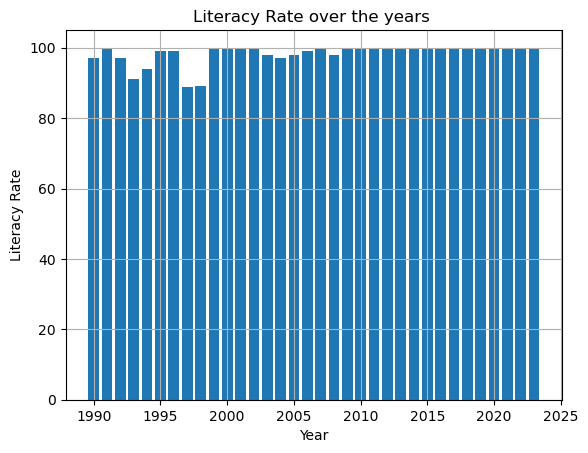

In [349]:
#Literacy Rate over the years 
plt.bar(df_education_index["year"], df_education_index["Literacy Rate"])
plt.xlabel('Year')
plt.ylabel('Literacy Rate')
plt.title('Literacy Rate over the years ')
plt.grid()
plt.show()

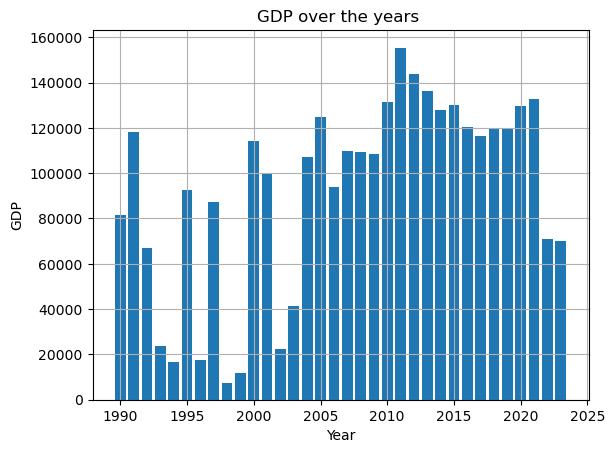

In [351]:
#GDP over the years
plt.bar(df_education_index["year"], df_education_index["GDP"])
plt.xlabel('Year')
plt.ylabel('GDP')
plt.title('GDP over the years ')
plt.grid()
plt.show()

In [402]:
#Bivariate Analysis

<Axes: xlabel='GDP', ylabel='Literacy Rate'>

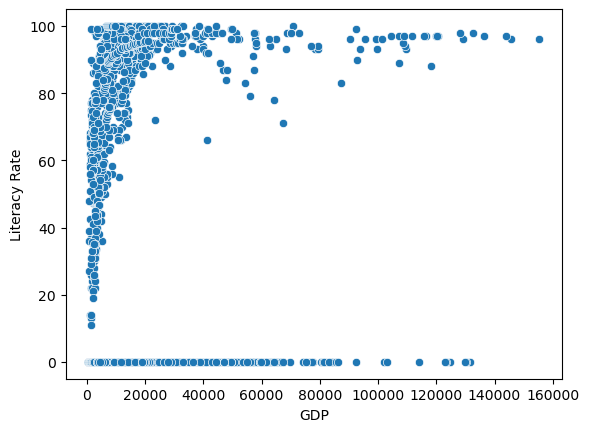

In [403]:
#GDP vs Literacy Rate
sns.scatterplot(data= df_education_index, x='GDP', y ='Literacy Rate')

<Axes: >

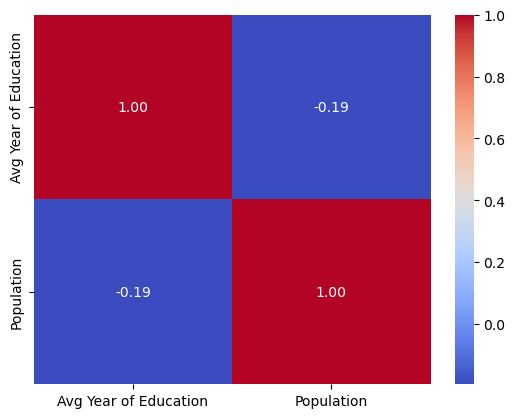

In [415]:
#heatmaps of correlations Population and Literacy Index
column = ["Avg Year of Education", "Population"]
corr = df_education_index[column].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

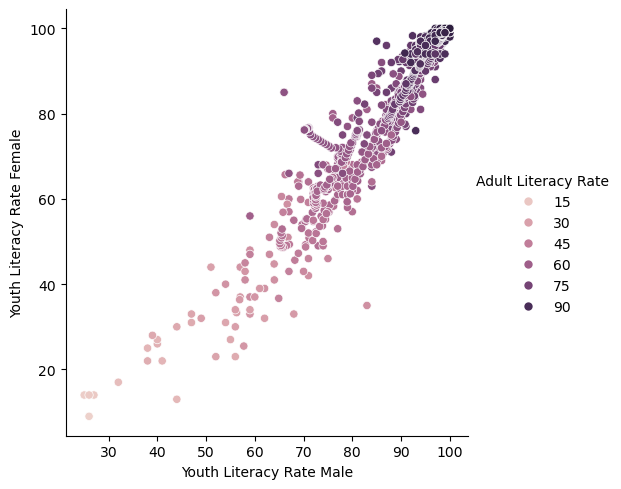

In [77]:
sns.relplot(data = df_literacy, x = 'Youth Literacy Rate Male', y = 'Youth Literacy Rate Female', hue = 'Adult Literacy Rate')

<Axes: xlabel='Avg Year of Education', ylabel='Count'>

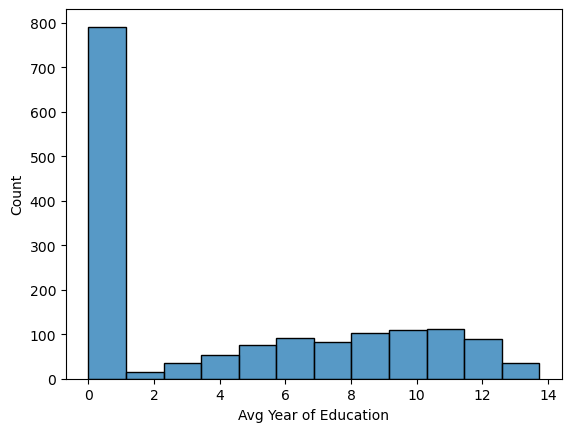

In [81]:
sns.histplot(df_education_index['Avg Year of Education'])

<Axes: ylabel='Education Index %'>

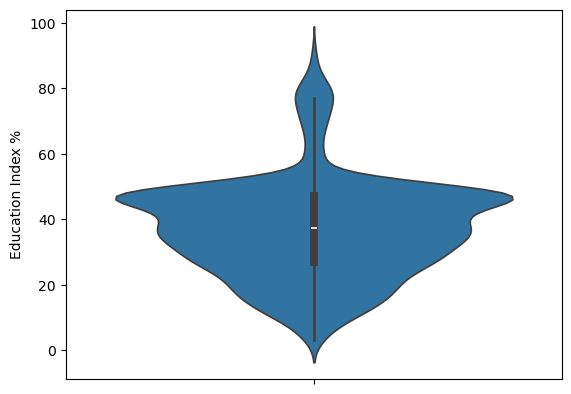

In [84]:
sns.violinplot(df_education_index['Education Index %'])

<Axes: xlabel='year', ylabel='Adult Literacy Rate'>

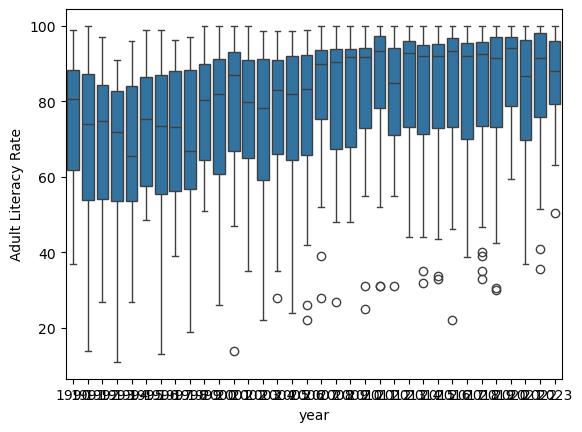

In [95]:
sns.boxplot(data = df_literacy, x = 'year', y = 'Adult Literacy Rate')

In [416]:
#Data Storage in SQL 🗄️
#Create 3 tables:
#literacy_rates 
#illiteracy_population
#gdp_schooling 

In [2]:
!pip install pymysql
!pip install mysql-connector-python
import pymysql
connection = pymysql.connect(
    host = "localhost",
    user = "root",
    password = "ashika",
    #database = "Global_Literacy_Educational_Trend"
)
mycursor = connection.cursor()
mycursor.execute("CREATE DATABASE Global_Literacy_Educational_Trend")


ProgrammingError: (1007, "Can't create database 'global_literacy_educational_trend'; database exists")

In [3]:
mycursor.execute("USE Global_Literacy_Educational_Trend")

0

In [499]:
#mycursor.execute("DROP TABLE gdp_schooling")

In [465]:
#Table 1: literacy_rates
mycursor.execute("""CREATE TABLE literacy_rates(
    country VARCHAR(100),
    code VARCHAR(10),
    year INT,
    Adult_literacy_rate DECIMAL(5,2),
    Youth_literacy_rate_male DECIMAL(5,2),
    Youth_literacy_rate_female DECIMAL(5,2),
    owid_region VARCHAR(100),
    PRIMARY KEY (country, year))""")

0

In [469]:
#Table 2: illiteracy_population
mycursor.execute("""CREATE TABLE illiteracy_population (
    country VARCHAR(100),
     code VARCHAR(10),
    year INT,
    Illiteracy_rate DECIMAL(5,2),
    Literacy_rate DECIMAL(5,2),
    Literacy_growth_rate DECIMAL(5,2),		
    PRIMARY KEY (country, year))""")



0

In [500]:
#Table 3: gdp_schooling
mycursor.execute("""CREATE TABLE gdp_schooling (
    country VARCHAR(100),
    code VARCHAR(10),
    year INT,
    GDP DECIMAL(12,2),
    owid_region VARCHAR(100),
    Literacy_rate DECIMAL(5,2),
    avg_years_schooling DECIMAL(5,2),
    Population DECIMAL(50,6),
    Literacy_Index DECIMAL(5,2),
    Education_year_Index DECIMAL(5,2),
    Education_Index_percentage DECIMAL(5,2),
    PRIMARY KEY (country, year)
)""")

0

In [466]:
li_rate_sql = "INSERT INTO literacy_rates VALUES(%s, %s, %s, %s, %s, %s, %s)"
lit_rate_data = [tuple(row_1) for row_1 in df_literacy.values]
mycursor.executemany(li_rate_sql, lit_rate_data)
connection.commit()

In [485]:
Illit_rate_sql = "INSERT INTO illiteracy_population VALUES(%s, %s, %s, %s, %s, %s)"
Illit_rate_data = [tuple(row_1) for row_1 in df_illiteracy.values]
mycursor.executemany(Illit_rate_sql, Illit_rate_data)
connection.commit()

In [501]:
gdp_schooling_sql = "INSERT INTO gdp_schooling VALUES(%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)"
gdp_schooling_data = [tuple(row_1) for row_1 in df_gdp_schooling.values]
mycursor.executemany(gdp_schooling_sql, gdp_schooling_data)
connection.commit()

In [ ]:
#SQL Queries 🧮

In [450]:
#literacy_rates

In [503]:
#Get top 5 countries with highest adult literacy in 2020.
top_5_country = mycursor.execute("SELECT country, Adult_literacy_rate from literacy_rates WHERE year = 2020 ORDER BY Adult_literacy_rate DESC LIMIt 5")
top_5_country = mycursor.fetchall()
top_5_country

(('Armenia', Decimal('100.00')),
 ('Mongolia', Decimal('99.00')),
 ('Spain', Decimal('99.00')),
 ('North America (WB)', Decimal('98.77')),
 ('Europe and Northern America (SDG)', Decimal('98.67')))

In [508]:
#Find countries where female youth literacy < 80%
female_Youth_lit = mycursor.execute("SELECT DISTINCT country from literacy_rates WHERE Youth_literacy_rate_female < 80 ")
female_Youth_lit = mycursor.fetchall()
female_Youth_lit

(('Afghanistan',),
 ('Angola',),
 ('Bangladesh',),
 ('Belize',),
 ('Benin',),
 ('Bhutan',),
 ('Burkina Faso',),
 ('Burundi',),
 ('Cambodia',),
 ('Cameroon',),
 ('Central African Republic',),
 ('Central and Southern Asia (SDG)',),
 ('Chad',),
 ('Comoros',),
 ('Congo',),
 ("Cote d'Ivoire",),
 ('Democratic Republic of Congo',),
 ('East Timor',),
 ('Egypt',),
 ('Eritrea',),
 ('Ethiopia',),
 ('Gambia',),
 ('Ghana',),
 ('Guatemala',),
 ('Guinea',),
 ('Guinea-Bissau',),
 ('India',),
 ('Iraq',),
 ('Laos',),
 ('Low-income countries',),
 ('Lower-middle-income countries',),
 ('Madagascar',),
 ('Malawi',),
 ('Mali',),
 ('Mauritania',),
 ('Middle East and North Africa (WB)',),
 ('Middle-income countries',),
 ('Morocco',),
 ('Mozambique',),
 ('Nepal',),
 ('Niger',),
 ('Nigeria',),
 ('Northern Africa and Western Asia (SDG)',),
 ('Oceania (excluding Australia and New Zealand) (SDG)',),
 ('Pakistan',),
 ('Papua New Guinea',),
 ('Rwanda',),
 ('Senegal',),
 ('Sierra Leone',),
 ('Somalia',),
 ('South Asia

In [513]:
#Average adult literacy per continent (owid region).
Adult_it_continent = mycursor.execute("SELECT owid_region, AVG(Adult_literacy_rate) AS avg_adult FROM literacy_rates GROUP BY owid_region ORDER BY avg_adult DESC")
Adult_it_continent = mycursor.fetchall()
Adult_it_continent

(('Europe', Decimal('97.396622')),
 ('South America', Decimal('93.467009')),
 ('Oceania', Decimal('93.445556')),
 ('North America', Decimal('87.986163')),
 ('Asia', Decimal('87.146557')),
 ('0', Decimal('77.044642')),
 ('Africa', Decimal('60.913973')))

In [514]:
#illiteracy_population

In [5]:
#Countries with illiteracy % > 20% in 2000.
illit_20_2000 = mycursor.execute("SELECT country, Illiteracy_rate FROM illiteracy_population WHERE Illiteracy_rate > 20 AND year = 2000")
illit_20_2000 = mycursor.fetchall()
illit_20_2000

(('Burundi', Decimal('41.00')),
 ('Cameroon', Decimal('32.00')),
 ('Central African Republic', Decimal('49.00')),
 ('Central and Southern Asia (SDG)', Decimal('39.92')),
 ('Chad', Decimal('74.00')),
 ('Comoros', Decimal('32.00')),
 ("Cote d'Ivoire", Decimal('51.00')),
 ('Gambia', Decimal('63.00')),
 ('Ghana', Decimal('42.00')),
 ('Guinea-Bissau', Decimal('59.00')),
 ('Iraq', Decimal('26.00')),
 ('Laos', Decimal('30.00')),
 ('Low-income countries', Decimal('48.60')),
 ('Lower-middle-income countries', Decimal('37.20')),
 ('Madagascar', Decimal('29.00')),
 ('Mauritania', Decimal('49.00')),
 ('Middle East and North Africa (WB)', Decimal('30.60')),
 ('Middle-income countries', Decimal('21.02')),
 ('Northern Africa and Western Asia (SDG)', Decimal('27.84')),
 ('Oceania (excluding Australia and New Zealand) (SDG)', Decimal('34.65')),
 ('Papua New Guinea', Decimal('43.00')),
 ('Rwanda', Decimal('35.00')),
 ('Saudi Arabia', Decimal('21.00')),
 ('South Asia (WB)', Decimal('42.35')),
 ('Sub-Saha

In [4]:
#Trend of illiteracy % for India (2000–2020).
illit_india_trend =  mycursor.execute("SELECT Illiteracy_rate,year FROM illiteracy_population WHERE country = 'India' AND YEAR BETWEEN 2000 AND 2020")
illit_india_trend = mycursor.fetchall()
illit_india_trend

((Decimal('39.00'), 2001), (Decimal('37.00'), 2006), (Decimal('31.00'), 2011))

In [6]:
#Top 10 countries with largest illiterate population in the last year
Top_10_illetrate = mycursor.execute("SELECT country, Illiteracy_rate FROM illiteracy_population WHERE year = 2023 ORDER BY Illiteracy_rate DESC LIMIT 10")
Top_10_illetrate = mycursor.fetchall()
Top_10_illetrate

(('Senegal', Decimal('49.64')),
 ('Low-income countries', Decimal('36.96')),
 ('Sub-Saharan Africa (WB)', Decimal('31.80')),
 ('Sub-Saharan Africa (SDG)', Decimal('31.50')),
 ('South Asia (WB)', Decimal('24.99')),
 ('Central and Southern Asia (SDG)', Decimal('23.49')),
 ('Lower-middle-income countries', Decimal('22.37')),
 ('Middle East and North Africa (WB)', Decimal('19.05')),
 ('Northern Africa and Western Asia (SDG)', Decimal('18.47')),
 ('India', Decimal('18.00')))

In [35]:
#gdp_schooling

In [13]:
#Find countries with avg_years_schooling > 7 and gdp_per_capita < 5000
avg_schooling_7years = mycursor.execute("SELECT country FROM gdp_schooling WHERE avg_years_schooling > 7 AND GDP < 5000 GROUP BY country")
avg_schooling_7years = mycursor.fetchall()
avg_schooling_7years

(('Cameroon',),
 ('China',),
 ('Ghana',),
 ('Lesotho',),
 ('Philippines',),
 ('Sri Lanka',),
 ('Syria',),
 ('Tajikistan',),
 ('Togo',),
 ('Zambia',),
 ('Zimbabwe',))

In [53]:
#Rank countries by GDP per schooling for the year 2020
GDP_per_Schooling = mycursor.execute("SELECT country, (GDP/avg_years_schooling) AS GDP_per_Schooling, RANK() OVER (ORDER BY (GDP/avg_Years_schooling) DESC) AS 'rank' FROM gdp_schooling WHERE year = 2020 ORDER BY GDP_per_Schooling DESC")
GDP_per_Schooling = mycursor.fetchall()
GDP_per_Schooling

(('Qatar', Decimal('12096.467136'), 1),
 ('Luxembourg', Decimal('11263.281006'), 2),
 ('Singapore', Decimal('8873.892802'), 3),
 ('Brunei', Decimal('8650.959052'), 4),
 ('Kuwait', Decimal('7458.129909'), 5),
 ('Ireland', Decimal('7421.292576'), 6),
 ('Norway', Decimal('7127.157285'), 7),
 ('United Arab Emirates', Decimal('6981.050157'), 8),
 ('Bahrain', Decimal('6554.719854'), 9),
 ('Switzerland', Decimal('5961.826523'), 10),
 ('Saudi Arabia', Decimal('5823.603448'), 11),
 ('Austria', Decimal('5801.386910'), 12),
 ('Denmark', Decimal('5623.989735'), 13),
 ('Netherlands', Decimal('5487.494924'), 14),
 ('Macao', Decimal('5438.694622'), 15),
 ('United States', Decimal('5055.710961'), 16),
 ('Sweden', Decimal('5027.272422'), 17),
 ('Finland', Decimal('5015.824434'), 18),
 ('Belgium', Decimal('4955.362143'), 19),
 ('Hong Kong', Decimal('4780.088075'), 20),
 ('Germany', Decimal('4595.670992'), 21),
 ('Australia', Decimal('4428.497293'), 22),
 ('Iceland', Decimal('4400.872875'), 23),
 ('New Z

In [54]:
#Find global average schooling years per year
avg_schooling_year = mycursor.execute("SELECT year, AVG(avg_years_schooling) AS average_schooling FROM gdp_schooling GROUP BY year ORDER BY year")
avg_schooling_year = mycursor.fetchall()
avg_schooling_year

((1990, Decimal('6.231964')),
 (1991, Decimal('0.000000')),
 (1992, Decimal('0.000000')),
 (1993, Decimal('0.000000')),
 (1994, Decimal('0.000000')),
 (1995, Decimal('6.844324')),
 (1996, Decimal('0.000000')),
 (1997, Decimal('0.000000')),
 (1998, Decimal('0.000000')),
 (1999, Decimal('0.000000')),
 (2000, Decimal('6.135909')),
 (2001, Decimal('0.000000')),
 (2002, Decimal('0.000000')),
 (2003, Decimal('0.000000')),
 (2004, Decimal('0.000000')),
 (2005, Decimal('7.523304')),
 (2006, Decimal('0.000000')),
 (2007, Decimal('0.000000')),
 (2008, Decimal('0.000000')),
 (2009, Decimal('0.000000')),
 (2010, Decimal('7.547934')),
 (2011, Decimal('0.000000')),
 (2012, Decimal('0.000000')),
 (2013, Decimal('0.000000')),
 (2014, Decimal('0.000000')),
 (2015, Decimal('8.386424')),
 (2016, Decimal('0.000000')),
 (2017, Decimal('0.000000')),
 (2018, Decimal('0.000000')),
 (2019, Decimal('0.000000')),
 (2020, Decimal('9.020890')),
 (2021, Decimal('0.000000')),
 (2022, Decimal('0.000000')),
 (2023, De

In [55]:
#Join Queries 

In [16]:
# List top 10 countries in 2020 with highest GDP per capita but lowest average years of schooling(less than 6)
query_1 = mycursor.execute("SELECT country, avg_Years_schooling, GDP FROM gdp_schooling WHERE year = 2020 AND avg_Years_schooling < 6 ORDER BY GDP DESC LIMIT 10")
query_1 = mycursor.fetchall()
query_1

(('Oman', Decimal('0.00'), Decimal('37560.60')),
 ('Upper-middle-income countries', Decimal('0.00'), Decimal('18242.54')),
 ('Lower-middle-income countries', Decimal('0.00'), Decimal('7439.81')),
 ('Cambodia', Decimal('5.81'), Decimal('6128.78')),
 ('Mauritania', Decimal('5.55'), Decimal('5963.24')),
 ('Palestine', Decimal('0.00'), Decimal('5423.68')),
 ('Papua New Guinea', Decimal('4.84'), Decimal('4077.63')),
 ('Senegal', Decimal('4.40'), Decimal('4018.04')),
 ('Sudan', Decimal('4.38'), Decimal('3401.25')),
 ('Haiti', Decimal('5.95'), Decimal('3239.84')))

In [17]:
#Show countries where the illiterate population is high despite having more than 10 average years of schooling.
query_2 = mycursor.execute("SELECT I.country, I.Illiteracy_rate FROM illiteracy_population AS I JOIN gdp_schooling AS G on I.country = G.country AND I.year = G.year WHERE G.avg_Years_schooling >10 ORDER BY I.Illiteracy_rate DESC")
query_2 = mycursor.fetchall()
query_2

(('Malta', Decimal('12.00')),
 ('Belize', Decimal('9.08')),
 ('Sri Lanka', Decimal('9.00')),
 ('Malta', Decimal('8.00')),
 ('Sri Lanka', Decimal('8.00')),
 ('Malaysia', Decimal('7.00')),
 ('South Africa', Decimal('6.00')),
 ('Mexico', Decimal('5.00')),
 ('Colombia', Decimal('4.00')),
 ('Chile', Decimal('3.00')),
 ('Singapore', Decimal('3.00')),
 ('Singapore', Decimal('3.00')),
 ('Spain', Decimal('2.00')),
 ('Spain', Decimal('2.00')),
 ('Spain', Decimal('2.00')),
 ('Spain', Decimal('1.00')),
 ('Armenia', Decimal('0.00')),
 ('Russia', Decimal('0.00')))

In [67]:
#Compare literacy rates and GDP per capita growth for a selected country over the last 20 years. (country of your choice)
query_3 = mycursor.execute("SELECT L.year, L.Adult_literacy_rate, G.GDP FROM literacy_rates AS L JOIN gdp_schooling AS G ON L.country = G.country AND L.year = G.year WHERE L.country = 'Spain' AND L.year BETWEEN 2003 AND 2023 ORDER BY L.year") 
query_3 = mycursor.fetchall()
query_3

((2004, Decimal('97.00'), Decimal('42793.39')),
 (2005, Decimal('98.00'), Decimal('43570.77')),
 (2006, Decimal('98.00'), Decimal('44572.68')),
 (2007, Decimal('98.00'), Decimal('45301.29')),
 (2008, Decimal('98.00'), Decimal('44926.35')),
 (2009, Decimal('98.00'), Decimal('42852.22')),
 (2010, Decimal('98.00'), Decimal('42695.53')),
 (2011, Decimal('98.00'), Decimal('42271.84')),
 (2012, Decimal('98.00'), Decimal('41034.05')),
 (2013, Decimal('98.00'), Decimal('40594.91')),
 (2014, Decimal('98.00'), Decimal('41339.41')),
 (2015, Decimal('98.00'), Decimal('43053.76')),
 (2016, Decimal('98.00'), Decimal('44274.67')),
 (2018, Decimal('98.00'), Decimal('46325.21')),
 (2020, Decimal('99.00'), Decimal('41553.45')),
 (2021, Decimal('100.00'), Decimal('44251.66')))

In [69]:
#Show the difference between youth literacy male and female rates for countries with GDP per capita above $30,000 in 2020.
query_4 = mycursor.execute("SELECT L.country,L.Youth_literacy_rate_female,  L.Youth_literacy_rate_male, (L.Youth_literacy_rate_female - L.Youth_literacy_rate_male) AS diff, G.GDP FROM literacy_rates As L JOIN gdp_schooling AS G ON L.country = G.country AND L.year = G.year WHERE G.year = 2020 AND G.GDP > 30000 ORDER BY diff DESC") 
query_4 = mycursor.fetchall()
query_4

(('Kuwait',
  Decimal('100.00'),
  Decimal('99.00'),
  Decimal('1.00'),
  Decimal('49372.82')),
 ('Spain',
  Decimal('100.00'),
  Decimal('99.00'),
  Decimal('1.00'),
  Decimal('41553.45')),
 ('Oman',
  Decimal('100.00'),
  Decimal('100.00'),
  Decimal('0.00'),
  Decimal('37560.60')),
 ('Singapore',
  Decimal('100.00'),
  Decimal('100.00'),
  Decimal('0.00'),
  Decimal('115893.04')),
 ('Saudi Arabia',
  Decimal('99.00'),
  Decimal('100.00'),
  Decimal('-1.00'),
  Decimal('57420.73')))